# Lab 10 — MIMO: Diversity, Multiplexing, Beamforming and Massive MIMO

**Companion to Chapter 19** (*MIMO and Antenna Arrays*).
**Time needed:** about 75 minutes. **Difficulty:** advanced.

Multiple antennas give three different things, and good engineers never confuse them:
**diversity** (independent fades averaged, so the error curve gets steeper), **array gain**
(coherent combining, so the SNR goes up) and **spatial multiplexing** (several streams through
the same bandwidth, so capacity grows linearly with the number of antennas). This lab measures all
three, then scales up to the 64-antenna arrays of 5G massive MIMO. The B200 has one TX and one RX
chain, so this lab is simulation-only (a B210 or two synchronised USRPs are needed over the air).

### What you will learn
1. Measure diversity order with maximum-ratio combining and Alamouti space-time coding.
2. Compute ergodic and outage capacity, and water-filling over eigen-channels.
3. Compare ZF, MMSE, ordered MMSE-SIC and ML detection for spatial multiplexing.
4. Steer a uniform linear array and control its sidelobes.
5. Observe channel hardening and compare multi-user precoders in massive MIMO.

### Prerequisites
Lab 5 (Rayleigh fading), Lab 2 (detection). Linear algebra: SVD, eigenvalues. Chapter 19.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Diversity: the slope of the BER curve | |
| 2 | MIMO capacity | |
| 3 | SVD precoding and water-filling | yes |
| 4 | Detection for spatial multiplexing | |
| 5 | Beamforming with a uniform linear array | yes |
| 6 | Massive MIMO: hardening and multi-user precoding | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb
from scipy.signal.windows import chebwin
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=10, lab="10")
qpsk = cl.get_constellation("qpsk")

Lab 10 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 10


## 1. Diversity: the slope of the BER curve

With $L$ independent Rayleigh branches and maximum-ratio combining (weights $h_\ell^*$), the
combined SNR is $\sum_\ell|h_\ell|^2\,E_s/N_0$ and the bit error rate of BPSK/QPSK is

$$P_b = \left(\frac{1-\mu}{2}\right)^L\sum_{k=0}^{L-1}\binom{L-1+k}{k}\left(\frac{1+\mu}{2}\right)^k,\qquad
\mu = \sqrt{\frac{\bar\gamma_b}{1+\bar\gamma_b}},$$

which falls as $\bar\gamma^{-L}$: diversity order $L$. **Alamouti's** 2×1 code achieves order 2 with
two *transmit* antennas and no channel knowledge at the transmitter, 3 dB behind 1×2 MRC because
the power is split between the antennas.

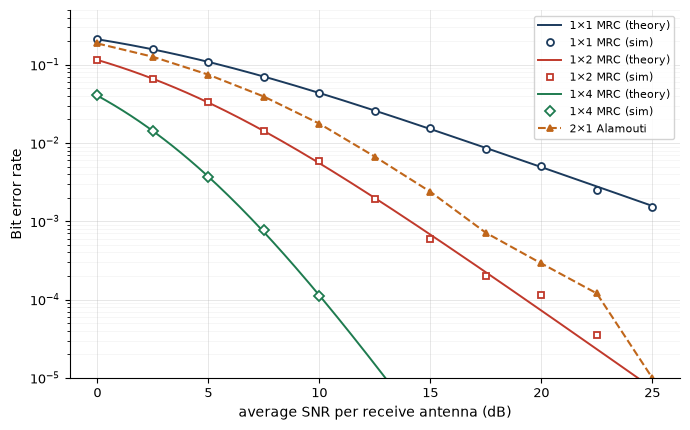

In [3]:
def ber_mrc_theory(snr_db, L):
    g = lk.undb(snr_db) / 2                      # SNR per bit per branch (QPSK: Es = 2 Eb)
    mu = np.sqrt(g / (1 + g))
    return ((1 - mu) / 2) ** L * sum(comb(L - 1 + k, k) * ((1 + mu) / 2) ** k for k in range(L))

snr = np.arange(0, 26, 2.5)
snf = np.linspace(0, 25, 200)
n = 100_000
bits = cl.random_bits(2 * n, rng)
s = qpsk.modulate(bits)
sims, th = {}, {}
for L in [1, 2, 4]:
    ber = []
    for e in snr:
        n0 = 10 ** (-e / 10)
        h = cl.rayleigh_mimo(L, n, rng=rng)
        r = h * s + np.sqrt(n0 / 2) * (rng.standard_normal((L, n)) + 1j * rng.standard_normal((L, n)))
        ber.append(np.mean(qpsk.demodulate(cl.mrc(r, h)) != bits))
    sims[f"1×{L} MRC"], th[f"1×{L} MRC"] = ber, ber_mrc_theory(snf, L)
ber = []
for e in snr:
    n0 = 10 ** (-e / 10)
    tx = cl.alamouti_encode(s)
    hb = cl.rayleigh_mimo(n // 2, 2, rng=rng)                  # one channel per 2-symbol block
    r = np.sum(np.repeat(hb, 2, axis=0).T * tx, axis=0) + np.sqrt(n0 / 2) * (rng.standard_normal(n) + 1j * rng.standard_normal(n))
    ber.append(np.mean(qpsk.demodulate(cl.alamouti_decode(r, hb)) != bits))
sims["2×1 Alamouti"] = ber
f, ax = lk.fig("ber")
lk.ber_plot(ax, snr, sims, th, x_theory=snf, xlabel="average SNR per receive antenna (dB)", ylim=(1e-5, 0.5))
lk.show(f)

**What you should see.** Slopes of 1, 2 and 4 decades per 10 dB; markers on the theory lines;
Alamouti parallel to 1×2 MRC and 3 dB to its right.

### Try it yourself 1.1
Read the MRC formula: at an average SNR of 20 dB, by what factor does going from 1×1 to 1×2 reduce
the QPSK BER? (Use `ber_mrc_theory`.)

In [5]:
answer_1_1 = None
lk.check("1.1 BER ratio 1x1 / 1x2 at 20 dB", answer_1_1, ber_mrc_theory(20, 1) / ber_mrc_theory(20, 2), rtol=0.03)

[TODO] 1.1 BER ratio 1x1 / 1x2 at 20 dB: not attempted yet: replace the None with your answer

## 2. MIMO capacity

For $\mathbf{y} = \mathbf{H}\mathbf{x} + \mathbf{n}$ with no channel knowledge at the transmitter,
$C = \log_2\det\!\left(\mathbf{I} + \frac{\rho}{N_t}\mathbf{H}\mathbf{H}^H\right)$. At high SNR capacity grows as
$\min(N_t, N_r)\log_2\rho$: the **multiplexing gain**. The **outage capacity** $C_{10\%}$ is the rate
supported by 90% of channel realisations, the relevant figure for a slowly fading link.

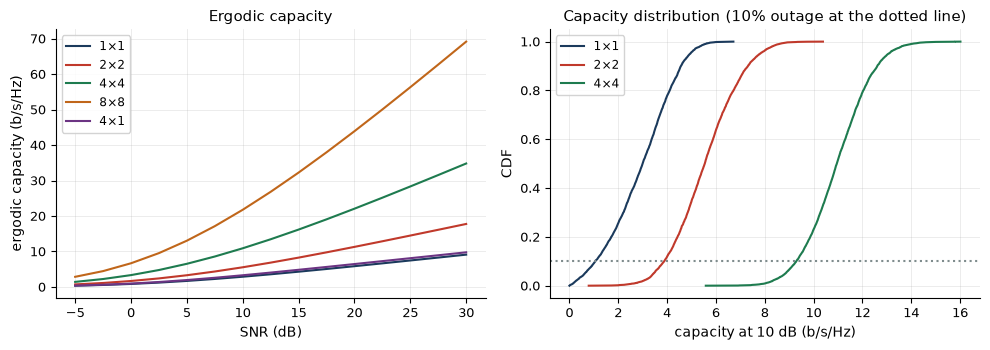

In [7]:
snr_db = np.arange(-5, 31, 2.5)
f, ax = lk.fig("row2", 1, 2)
for nt, nr in [(1, 1), (2, 2), (4, 4), (8, 8), (4, 1)]:
    H = cl.rayleigh_mimo(nr, nt, n=2000, rng=rng)
    ax[0].plot(snr_db, [np.mean(cl.capacity_equal_power(H, lk.undb(x_))) for x_ in snr_db], label=f"{nt}×{nr}")
ax[0].set_xlabel("SNR (dB)"); ax[0].set_ylabel("ergodic capacity (b/s/Hz)"); ax[0].legend()
ax[0].set_title("Ergodic capacity")
for nt, nr in [(1, 1), (2, 2), (4, 4)]:
    C = np.sort(cl.capacity_equal_power(cl.rayleigh_mimo(nr, nt, n=5000, rng=rng), 10))
    ax[1].plot(C, np.arange(1, len(C) + 1) / len(C), label=f"{nt}×{nr}")
ax[1].axhline(0.1, color=lk.GRAY, ls=":"); ax[1].set_xlabel("capacity at 10 dB (b/s/Hz)"); ax[1].set_ylabel("CDF")
ax[1].set_title("Capacity distribution (10% outage at the dotted line)"); ax[1].legend()
lk.show(f)

**What you should see.** At 30 dB the 4×4 curve gives nearly four times the 1×1 capacity; 4×1
(transmit diversity only) gains a little but keeps the 1×1 slope. On the right, more antennas both
shift and *steepen* the CDF: the 10% outage capacity of 4×4 is far above that of 1×1.

### Try it yourself 2.1
For a 4×4 system at high SNR, how many b/s/Hz does capacity gain for every 3 dB of SNR?

In [9]:
answer_2_1 = None
lk.check("2.1 capacity slope of 4x4 per 3 dB", answer_2_1, 4 * np.log2(lk.undb(3)), atol=0.05)

[TODO] 2.1 capacity slope of 4x4 per 3 dB: not attempted yet: replace the None with your answer

## 3. SVD precoding and water-filling

With channel knowledge at the transmitter, $\mathbf{H} = \mathbf{U}\boldsymbol\Sigma\mathbf{V}^H$ turns the link
into parallel eigen-channels with gains $\lambda_i = \sigma_i^2$. **Water-filling** pours power into
them so that $p_i = (\mu - 1/\lambda_i)^+$: strong channels get more, very weak ones nothing.
Antenna correlation ρ shrinks the weaker singular values.

### Interactive

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

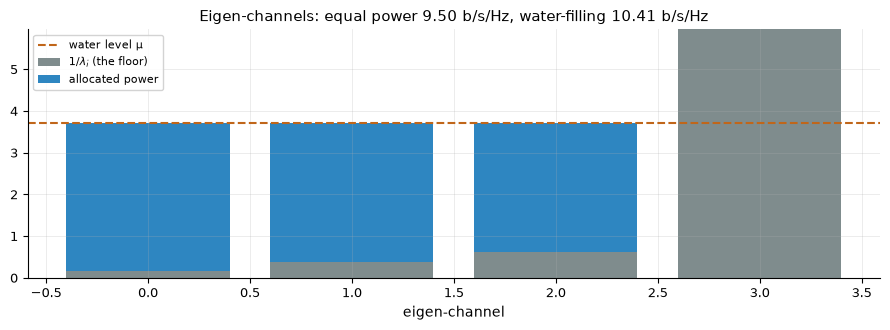

In [11]:
def wf_demo(nt=4, snr_db=10.0, rho=0.0, seed=0):
    H = cl.correlated_mimo(nt, nt, rho, rho, rng=np.random.default_rng(seed))
    g = np.linalg.svd(H, compute_uv=False) ** 2
    P = lk.undb(snr_db)
    p = cl.waterfill(g, P)
    base = 1 / g
    f, ax = lk.fig("wide")
    ax.bar(range(nt), base, color=lk.GRAY, label="$1/\\lambda_i$ (the floor)")
    ax.bar(range(nt), p, bottom=base, color=lk.BLUE, label="allocated power")
    mu_w = (P + np.sum(base[p > 0])) / max(np.sum(p > 0), 1)
    ax.axhline(mu_w, color=lk.ORANGE, ls="--", label="water level μ")
    ce, cw = cl.capacity_equal_power(H, P), cl.capacity_waterfilling(H, P)
    ax.set_title(f"Eigen-channels: equal power {ce:.2f} b/s/Hz, water-filling {cw:.2f} b/s/Hz")
    ax.set_xlabel("eigen-channel"); ax.legend(fontsize=8, loc="upper left"); ax.set_ylim(0, 1.6 * mu_w)
    lk.show(f)

lk.interact(wf_demo, nt=lk.islider(4, 2, 8, 1, "antennas"), snr_db=lk.slider(10, -10, 30, 1, "SNR (dB)"),
            rho=lk.slider(0.0, 0, 0.99, 0.05, "correlation ρ"), seed=lk.islider(0, 0, 20, 1, "channel seed"))

**What you should see.** At low SNR water-filling puts everything into the strongest eigen-channel
(beamforming) and beats equal power clearly; at high SNR the water is deep, the allocation nearly
equal, and the gain small. Raise ρ and the weak eigen-channels sink below the waterline.

## 4. Detection for spatial multiplexing

Two QPSK streams over a 2×2 Rayleigh channel. **ZF** inverts $\mathbf{H}$ and suffers noise
enhancement (diversity order $N_r - N_t + 1 = 1$); **MMSE** regularises; **ordered MMSE-SIC**
(V-BLAST) detects the strongest stream first and subtracts it; **ML** searches all $M^{N_t}$
candidates and achieves full receive diversity at exponential cost. Practical receivers use
sphere decoding or K-best in between.

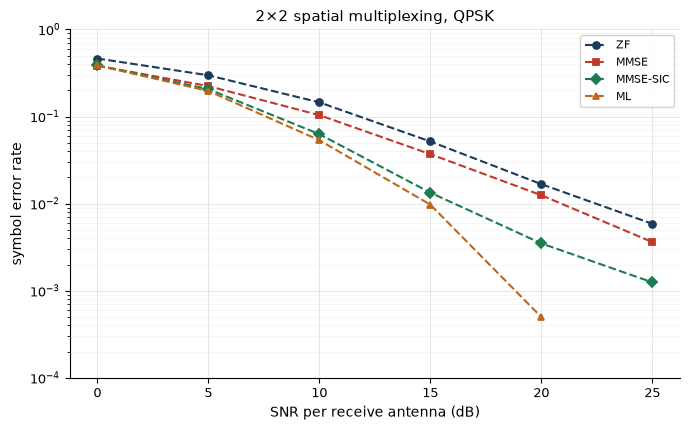

In [14]:
snr4 = np.arange(0, 26, 5.0)
res = {k: [] for k in ["ZF", "MMSE", "MMSE-SIC", "ML"]}
trials = 4000
for e in snr4:
    n0 = 2 * 10 ** (-e / 10)          # SNR per receive antenna = total TX power / n0
    errs = {k: 0 for k in res}
    for _ in range(trials):
        H = cl.rayleigh_mimo(2, 2, rng=rng)
        x = qpsk.points[rng.integers(0, 4, 2)]
        y = H @ x + np.sqrt(n0 / 2) * (rng.standard_normal(2) + 1j * rng.standard_normal(2))
        errs["ZF"] += np.sum(qpsk.decide(cl.zf_detect(H, y)) != x)
        errs["MMSE"] += np.sum(qpsk.decide(cl.mmse_detect(H, y, n0)) != x)
        errs["MMSE-SIC"] += np.sum(cl.mmse_sic_detect(H, y, n0, qpsk.points) != x)
        errs["ML"] += np.sum(cl.ml_detect(H, y, qpsk.points) != x)
    for k in res:
        res[k].append(errs[k] / (2 * trials))
f, ax = lk.fig("ber")
lk.ber_plot(ax, snr4, res, xlabel="SNR per receive antenna (dB)", ylabel="symbol error rate", ylim=(1e-4, 1))
ax.set_title("2×2 spatial multiplexing, QPSK")
lk.show(f)

**What you should see.** ZF and MMSE run parallel with slope 1 (MMSE a little ahead); SIC gains
more; ML shows a steeper, slope-2 curve. Already at $10^{-2}$ ML is about 6–7 dB ahead of ZF, and
the gap grows with SNR because the slopes differ.

## 5. Beamforming with a uniform linear array

Conjugate (matched) weights $\mathbf{w} = \mathbf{a}(\theta_0)$ give an array gain of $N$ in the look
direction. A taper (e.g. Chebyshev) trades main-lobe width for lower sidelobes. Element spacing
above $\lambda/2$ creates **grating lobes**: copies of the main beam in other directions.

### Interactive

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

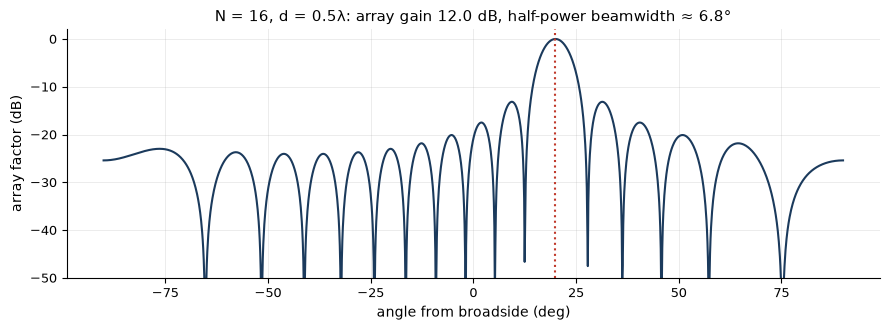

In [17]:
def beam(n=16, steer_deg=20.0, spacing=0.5, taper="uniform"):
    th = np.deg2rad(np.linspace(-90, 90, 1441))
    w = cl.ula_steering(n, np.deg2rad(steer_deg), spacing)[:, 0]
    if taper == "Chebyshev 30 dB":
        w = w * chebwin(n, 30)
    af = cl.array_factor_db(w, th, spacing)
    f, ax = lk.fig("wide")
    ax.plot(np.rad2deg(th), af); ax.set_ylim(-50, 2); ax.set_xlabel("angle from broadside (deg)")
    ax.set_ylabel("array factor (dB)"); ax.axvline(steer_deg, color=lk.RED, ls=":")
    ax.set_title(f"N = {n}, d = {spacing}λ: array gain {10 * np.log10(n):.1f} dB, half-power beamwidth ≈ "
                 f"{np.rad2deg(0.886 / (n * spacing * np.cos(np.deg2rad(steer_deg)))):.1f}°")
    lk.show(f)

lk.interact(beam, n=lk.islider(16, 2, 64, 1, "elements"), steer_deg=lk.slider(20, -80, 80, 1, "steer (deg)"),
            spacing=lk.slider(0.5, 0.1, 1.5, 0.05, "spacing (λ)"),
            taper=lk.choice(["uniform", "Chebyshev 30 dB"], desc="taper"))

**What you should see.** A main lobe at 20° with first sidelobes at −13 dB (uniform weights).
Chebyshev pushes them to −30 dB at the price of a wider main lobe. Set the spacing to 1λ and a
grating lobe of full height appears.

### Try it yourself 5.1
What is the approximate half-power beamwidth (degrees) of a 64-element, λ/2-spaced array steered to broadside?

In [19]:
answer_5_1 = None
lk.check("5.1 HPBW of 64 x λ/2 at broadside", answer_5_1, np.rad2deg(0.886 / (64 * 0.5)), rtol=0.03,
         hint="HPBW ≈ 0.886 / (N d/λ) radians")

[TODO] 5.1 HPBW of 64 x λ/2 at broadside: not attempted yet: replace the None with your answer

## 6. Massive MIMO: hardening and multi-user precoding

With $M$ base-station antennas and i.i.d. channels, $\|\mathbf{h}\|^2/M \to 1$ (**channel hardening**:
the effective channel stops fading) and $\mathbf{h}_1^H\mathbf{h}_2/M \to 0$ (**favourable propagation**:
users become orthogonal), so simple processing approaches optimal (Marzetta, 2010).

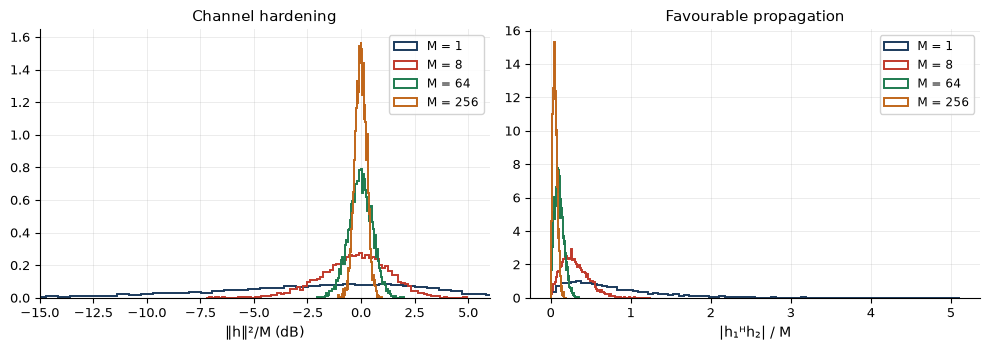

In [21]:
f, ax = lk.fig("row2", 1, 2)
for M in [1, 8, 64, 256]:
    h = cl.rayleigh_mimo(M, 1, n=5000, rng=rng)[:, :, 0]
    ax[0].hist(lk.db(np.sum(np.abs(h) ** 2, axis=1) / M), bins=80, density=True, histtype="step", lw=1.4, label=f"M = {M}")
    h2 = cl.rayleigh_mimo(M, 1, n=5000, rng=rng)[:, :, 0]
    ax[1].hist(np.abs(np.sum(np.conj(h) * h2, axis=1)) / M, bins=80, density=True, histtype="step", lw=1.4, label=f"M = {M}")
ax[0].set_xlabel("‖h‖²/M (dB)"); ax[0].set_title("Channel hardening"); ax[0].legend(); ax[0].set_xlim(-15, 6)
ax[1].set_xlabel("|h₁ᴴh₂| / M"); ax[1].set_title("Favourable propagation"); ax[1].legend()
lk.show(f)

### Multi-user downlink precoding
A base station with $M = 64$ antennas serves $K = 8$ single-antenna users at once. Precoder
$\mathbf{W}$ (columns normalised to equal power per user):
**maximum-ratio** (MR) $\mathbf{W} \propto \mathbf{H}^H$ maximises each user's signal but ignores
interference; **zero-forcing** $\mathbf{W} \propto \mathbf{H}^H(\mathbf{H}\mathbf{H}^H)^{-1}$ nulls it;
**regularised ZF** (RZF) $\mathbf{W} \propto \mathbf{H}^H(\mathbf{H}\mathbf{H}^H + \tfrac{K}{\rho}\mathbf{I})^{-1}$ balances.
The sum rate is $\sum_k\log_2(1+\mathrm{SINR}_k)$.

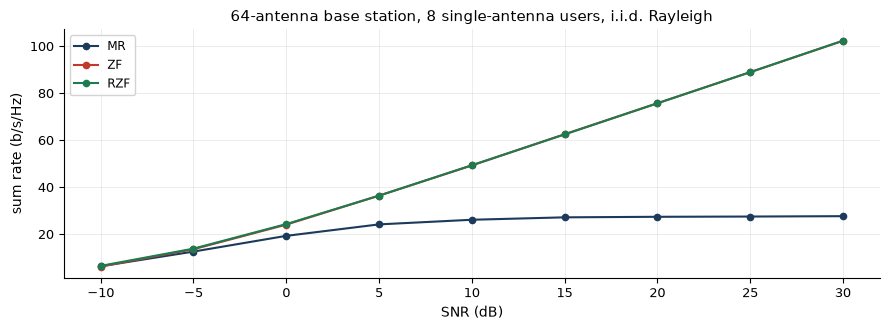

In [23]:
def sum_rate(M, K, snr_db, kind, trials=200):
    rho = lk.undb(snr_db)
    out = []
    for _ in range(trials):
        H = cl.rayleigh_mimo(K, M, rng=rng)                 # rows = users
        if kind == "MR":
            W = H.conj().T
        elif kind == "ZF":
            W = H.conj().T @ np.linalg.inv(H @ H.conj().T)
        else:
            W = H.conj().T @ np.linalg.inv(H @ H.conj().T + K / rho * np.eye(K))
        W = W / np.linalg.norm(W, axis=0, keepdims=True)     # unit power per user
        G = np.abs(H @ W) ** 2 * rho / K                     # total power rho split over K users
        sig = np.diag(G)
        out.append(np.sum(np.log2(1 + sig / (G.sum(axis=1) - sig + 1))))
    return np.mean(out)

snr6 = np.arange(-10, 31, 5.0)
f, ax = lk.fig("wide")
for kind in ["MR", "ZF", "RZF"]:
    ax.plot(snr6, [sum_rate(64, 8, e, kind) for e in snr6], "o-", label=kind)
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("sum rate (b/s/Hz)"); ax.legend()
ax.set_title("64-antenna base station, 8 single-antenna users, i.i.d. Rayleigh")
lk.show(f)

**What you should see.** At low SNR MR matches the others (noise dominates, interference does not
matter). At high SNR MR saturates, limited by residual inter-user interference, while ZF keeps
growing by about 8 b/s/Hz for every 3 dB: eight parallel streams. RZF is never worse than either
(at this antenna-to-user ratio its curve sits on top of ZF's). With $M/K = 8$
antennas per user the ZF penalty for nulling is small, which is why massive-MIMO base stations use ZF-like precoding.

## Key takeaways
* Diversity changes the *slope* of the error curve; array gain shifts it; multiplexing multiplies capacity.
* MRC with $L$ branches gives diversity $L$; Alamouti gives 2 with no transmitter CSI, 3 dB behind MRC.
* Capacity grows as $\min(N_t,N_r)\log_2\rho$; water-filling helps most at low SNR.
* ML detection achieves full diversity; linear detectors trade it for complexity.
* Massive MIMO hardens the channel and makes users nearly orthogonal; ZF/RZF precoding exploits it.

## Going further (hardware: USRP B200 / GNU Radio)
* The B200 is SISO. With a **B210** (2×2), GNU Radio's `UHD: USRP Source` with two channels and a
  shared LO lets you measure a real 2×2 channel matrix with a known preamble and compute its
  capacity with `cl.capacity_equal_power`.
* With one B200 you can still emulate receive diversity: capture the same transmitter at two
  antenna positions a few wavelengths apart and combine the recordings with MRC offline.

## Exercises
1. **(Warm-up)** Derive the 3 dB gap between Alamouti 2×1 and MRC 1×2.
2. **(Core)** Implement a K-best sphere decoder for 4×4 16-QAM and plot BER and average visited nodes
   against ML and MMSE-SIC.
3. **(Core)** Add channel-estimation error (MMSE estimate from $N_p$ pilots) and show how ZF and MMSE
   detection degrade with $N_p$.
4. **(Stretch)** Repeat Section 6 with a correlated channel (`cl.correlated_mimo`) and with pilot
   contamination between two cells. Which precoder is most robust?

In [26]:
lk.summary()

[good] Lab 10 finished in 12.3 s. Self-checks: 0 passed, 0 failed, 3 still to do.